# ReLU Activation Function. Vector Weights Norm Regularization.

In [116]:
# Check for all needed packages
import time

import IPython
import matplotlib
import mnists
import numpy

# In case of ImportError, install them to the running kernel with
# %pip install numpy matplotlib mnists
# or the the runtime container with:
# !pip install numpy matplotlib mnists
# (In case of the latter, remember to restart the kernel!)

# Tested in Python 3.14.3 with:
# numpy==2.4.3
# matplotlib==3.10.8
# mnists==0.4.1

In [117]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(1234)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = [16, 9]

### Handy utility functions

In [118]:
def append_ones(matrix: np.ndarray,  axis: int=1) -> np.ndarray:
    """
    Appends a column of ones to the right side of a 2D matrix.
    """
    return np.concatenate(
        (matrix, np.ones((matrix.shape[0], 1), dtype=np.float32)), axis=axis
    )


def zeros(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of zeros with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. zeros(3, 4) creates a (3, 4) array.
    """
    return np.zeros(shape=tuple(dims), dtype=np.float32)


def ones(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of ones with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. ones(3, 4) creates a (3, 4) array.
    """
    return np.ones(shape=tuple(dims), dtype=np.float32)


def rand(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of random values sampled from a uniform [0, 1) distribution.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. rand(3, 4) creates a (3, 4) array.
    """
    return np.random.rand(*dims).astype(np.float32)

def randn(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of random values sampled from a standard normal distribution.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. rand(3, 4) creates a (3, 4) array.
    """
    return np.random.randn(*dims).astype(np.float32)

def chunks(seq: list, size: int) -> tuple[np.ndarray]:
    """
    Splits a sequence into consecutive chunks of a given size.

    The last chunk may be smaller than `size` if the sequence length
    is not evenly divisible.

    Args:
        seq:  The input sequence (e.g. list or other sliceable) to split.
        size: The maximum number of elements in each chunk.

    Returns:
        Successive sub-sequences of length `size` (or less for the final chunk).
    """
    return tuple([seq[pos : (pos + size)] for pos in range(0, len(seq), size)])


def as_matrix(vector: np.ndarray) -> np.ndarray:
    """Reshape 1D vector to column matrix."""
    return np.reshape(vector, (-1, 1))


def one_hot_encode(labels: np.ndarray) -> np.ndarray:
    """Convert integer labels to one-hot encoded matrix."""
    (n_samples,) = labels.shape
    n_classes = np.max(labels) + 1

    one_hot = np.zeros((n_samples, n_classes), dtype=np.float32)
    one_hot[np.arange(n_samples), labels] = 1
    return one_hot

def classify(mlp: "MLP", batch: np.ndarray, forwad_pass_func) -> np.ndarray:
    """
    Classify a batch of inputs using the MLP model.

    Performs a forward pass to compute class probabilities, then returns
    the predicted class indices (argmax over probabilities).

    Args:
        mlp: Trained MLP model with forward_pass method.
        batch: Input data batch of shape (N, input_dim).

    Returns:
        Predicted class indices of shape (N,).
    """
    # Shape: (batch_size, num_classes)
    probabilities: np.ndarray = forwad_pass_func(mlp, batch, False)

    predictions = np.argmax(probabilities, axis=1)
    return predictions

def arrange_tiles_img(examples: np.ndarray) -> np.ndarray:
    """
    Arrange 2D matrices as tiles

    Takes 4D `examples` tensor with dims:
        rows x cols x tile_height x tile_width
    """
    rows_count = examples.shape[0]
    cols_count = examples.shape[1]
    tile_height = examples.shape[2]
    tile_width = examples.shape[3]

    space_between_tiles = 2
    img_matrix = np.empty(
        shape=(
            rows_count * (tile_height + space_between_tiles) - space_between_tiles,
            cols_count * (tile_width + space_between_tiles) - space_between_tiles,
        )
    )
    img_matrix.fill(np.nan)

    for r in range(rows_count):
        for c in range(cols_count):
            x_0 = r * (tile_height + space_between_tiles)
            y_0 = c * (tile_width + space_between_tiles)
            img_matrix[x_0 : x_0 + tile_height, y_0 : y_0 + tile_width] = examples[r, c]

    return img_matrix


def preview_tiles(examples: np.ndarray) -> None:
    """Previews the arrange tiles"""
    img = arrange_tiles_img(examples)
    plt.matshow(img, cmap="gray", interpolation="none")
    plt.axis("off")
    plt.show()

def draw_rbm_filters(rbm: "RestrictedBoltzmannMachine") -> None:
    filters = np.reshape(np.transpose(rbm.W)[:-1, :-1], newshape=(8, -1, 28, 28))
    preview_tiles(filters)

def draw_layer_filters(layer: "Layer") -> None:
    filters = np.reshape(layer.W[:-1].T, newshape=(8, -1, 28, 28))
    preview_tiles(filters)

### Activation functions

In [119]:
def sigmoid(batch: np.ndarray, stochastic: bool = False) -> np.ndarray:
    activations = 1.0 / (1.0 + np.exp(-batch))
    if stochastic:
        return activations > rand(*activations.shape).astype(np.float32)
    else:
        return activations

def sigmoid_derivative(batch):
    s = sigmoid(batch)
    return s * (1.0 - s)

def softmax(x: np.ndarray) -> np.ndarray:
    max_z = np.max(x, axis=1, keepdims=True)
    x = x - max_z
    exp_x = np.exp(x)

    sum_z = np.sum(exp_x, axis=1, keepdims=True)
    return exp_x / sum_z


# MNIST dataset

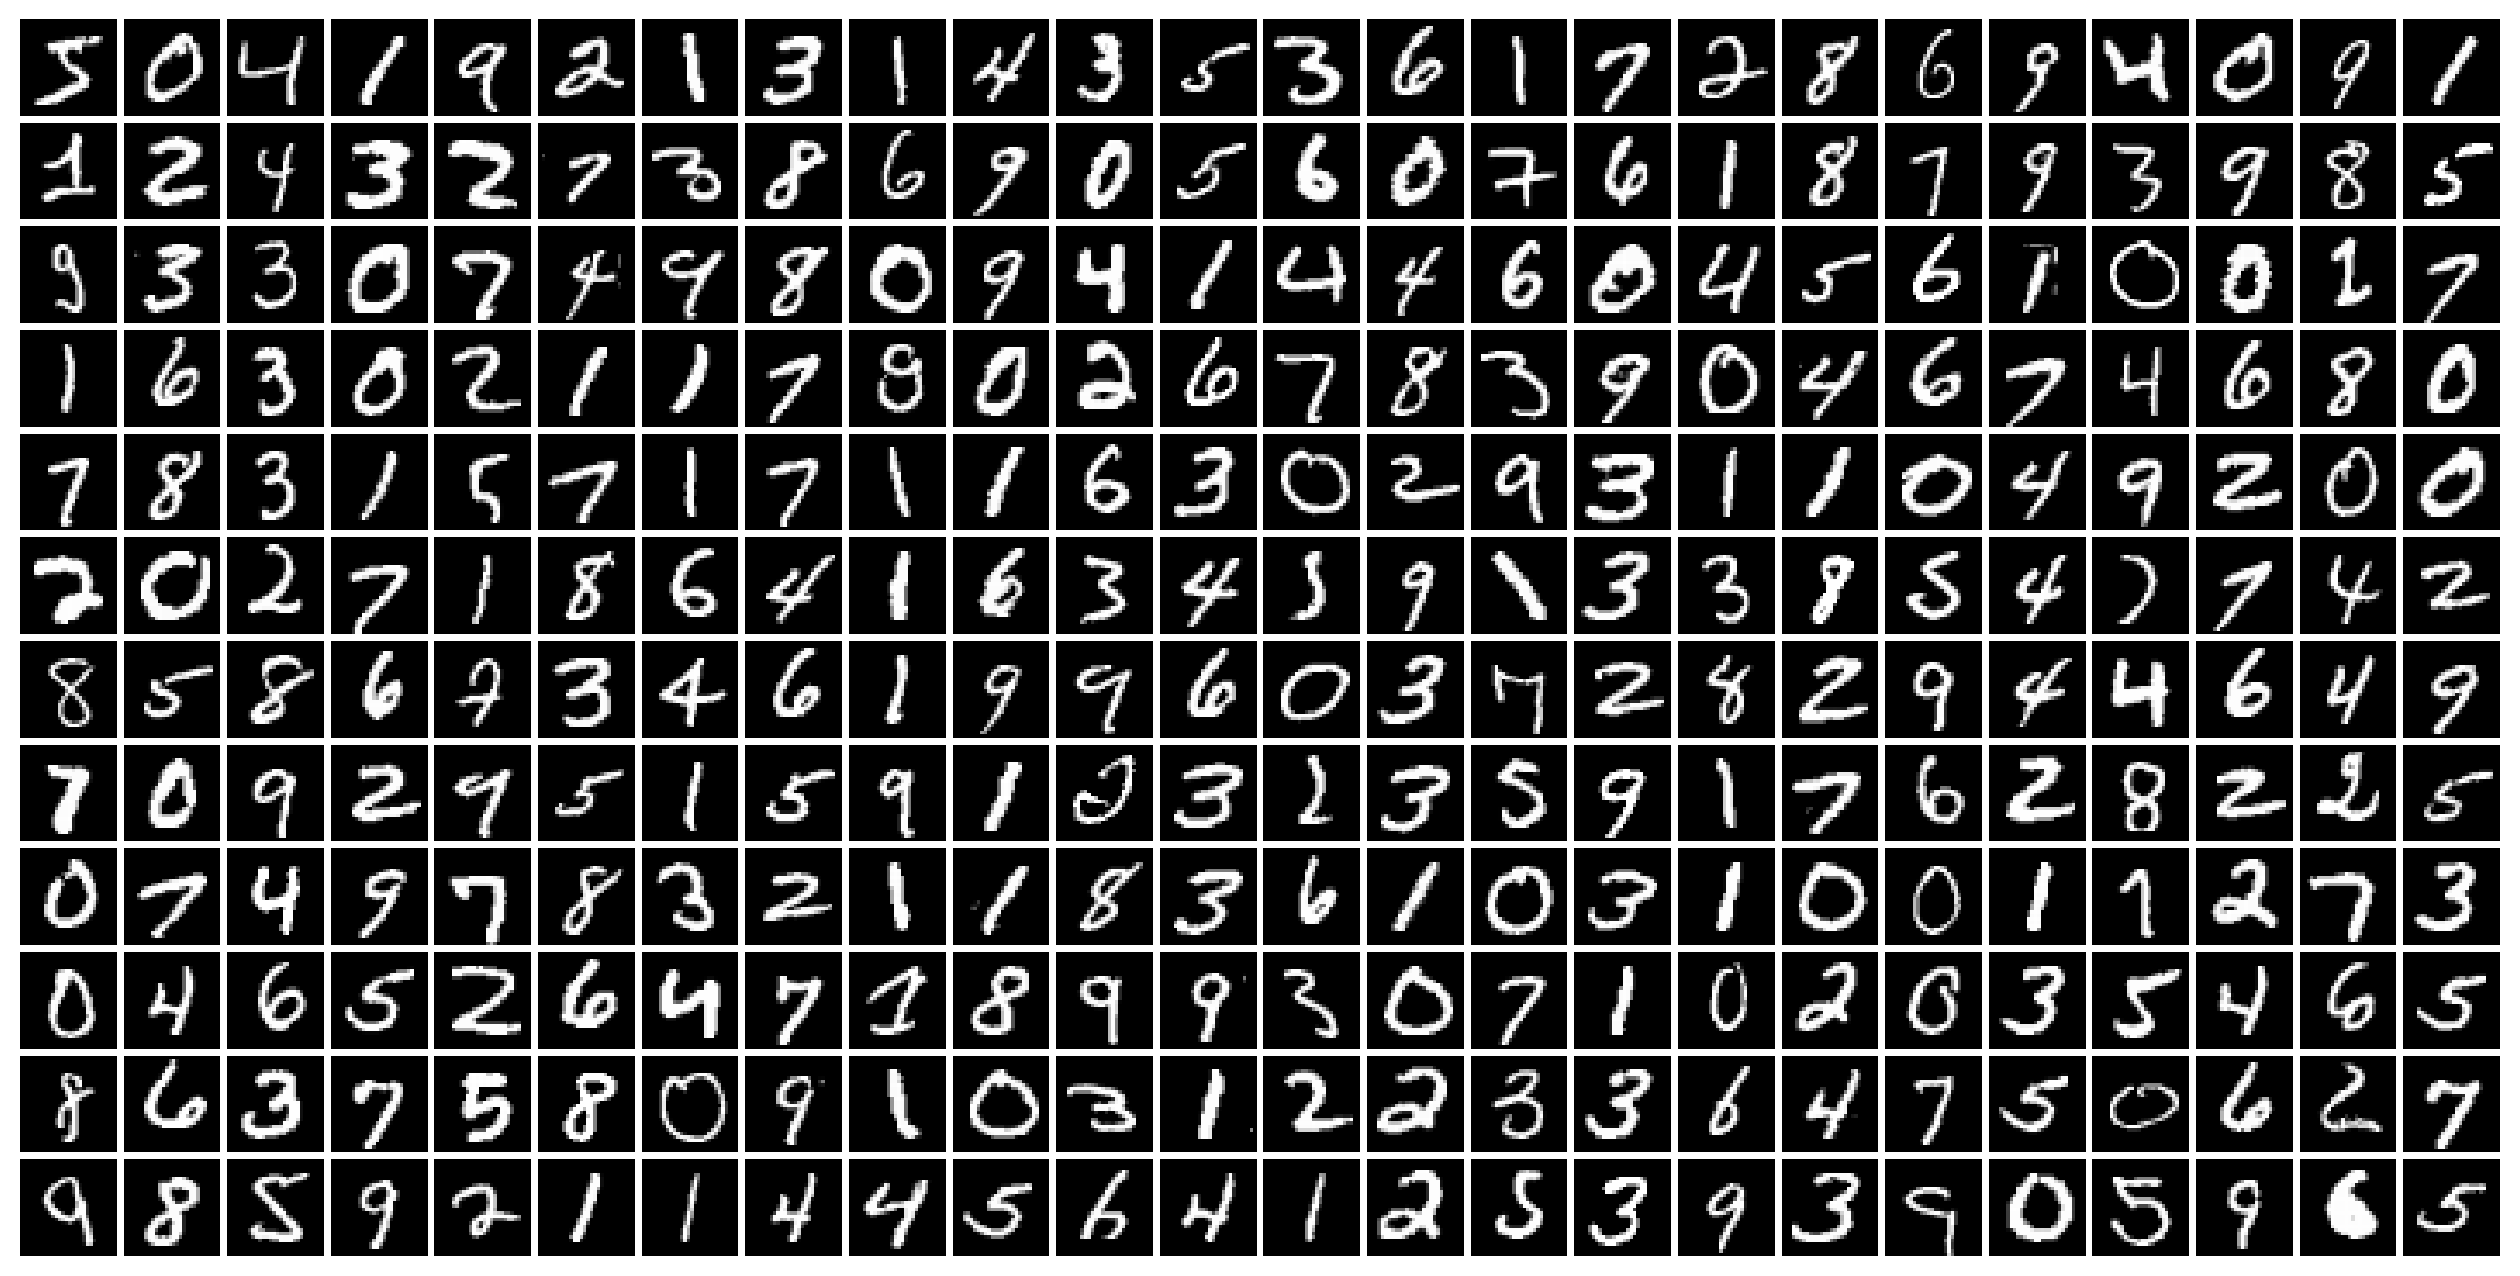

In [ ]:
from mnists import MNIST

mnist = MNIST()

PREVIEW_N_ROWS = 12
PREVIEW_N_COLS = 24
TILE_DIM = 28  # [px]

def create_mnist_digits(n_rows: int, n_cols: int, tile_dim: int) -> np.ndarray:
    shape = (n_rows, n_cols, tile_dim, tile_dim)
    return np.reshape(mnist.train_images()[: 12 * 24], newshape=shape)

mnist_digits = create_mnist_digits(PREVIEW_N_ROWS, PREVIEW_N_COLS, TILE_DIM)

preview_tiles(mnist_digits)

# ReLU and Max-Norm regularization

Stochastic ReLU: $ f(z) = z \cdot \mathbb{1}_{z>0} + \epsilon $

Standard: $ f(z) = \max(0, z) $

Stochastic: $ f(z) = z + \mathcal{N}(0, \sigma(z)) $

where $ \sigma(z) = \sqrt{sigmoid(z)} $



ReLU derivative: $ f'(z) = \mathbb{1}_{z>0} $

In [121]:
def relu(batch: np.ndarray, stochastic: bool = False) -> np.ndarray:
    """
    Stochastic ReLU
    """
    if stochastic:
        noise = randn(*batch.shape) * np.sqrt(sigmoid(batch))
        return np.maximum(0, batch + noise)
    return np.maximum(0, batch)

def relu_derivative(batch: np.ndarray) -> np.ndarray:
    """
    ReLU derivative
    """
    return (batch > 0).astype(float)

Weight normalization: $ W_{norm} = W / \max(1, ||W_{:,j}||/\lambda) $

Ensures $ ||W_{norm_{:,j}}||_2 \leq \lambda $ for each column $ j $

In [122]:
def limit_weights(weights: np.ndarray, lambda_limit: float) -> np.ndarray:
    """
    Weight normalization
    """
    if lambda_limit == 0:
        return weights

    column_norms = np.linalg.norm(weights, ord=2, axis=0)
    scale = np.minimum(1.0, lambda_limit / column_norms)

    return weights * scale

# RBM & DBN training

In [123]:
class RestrictedBoltzmannMachine:
    """
    A Restricted Boltzmann Machine (RBM) with a single visible and hidden layer.

    The weight matrix W has shape (visible_size + 1, hidden_size + 1), where
    the extra row and column are reserved for bias units.

    Attributes:
        visible_size:       Number of visible (input) units, excluding the bias.
        hidden_size:        Number of hidden units, excluding the bias.
        visible_act_func:   The activation function used within visible layer.
        hidden_act_func:    The activation function used within hidden layer.
        learning_rate:      Step size used during contrastive divergence updates.
        W:                  Weight matrix of shape (visible_size+1, hidden_size+1).
        momentum:           Momentum coefficient.
        weight_limit:       Weight limit normalization coefficient.
    """

    def __init__(
        self,
        visible_size: int,
        hidden_size: int,
        visible_act_func: callable,
        hidden_act_func: callable,
        learning_rate: float,
        momentum: float,
        weight_limit: float,
    ):
        self.visible_size = visible_size
        self.hidden_size = hidden_size

        self.visible_act_func = visible_act_func
        self.hidden_act_func = hidden_act_func

        self.learning_rate = learning_rate
        self.momentum = momentum

        self.weight_limit = weight_limit

        self.reset()

    def reset(self) -> None:
        self.W = np.random.normal(scale=0.01, size=(self.visible_size+1, self.hidden_size+1)).astype(np.float32)
        self.W[:, -1] = 0.0  # zero hidden-bias weights
        self.W[-1, :] = 0.0  # zero visible-bias weights
        self.M = zeros(self.visible_size+1, self.hidden_size+1)

In [124]:
from typing import TypeAlias
DBN: TypeAlias = list[RestrictedBoltzmannMachine]

In [125]:
def cdk(rbm: RestrictedBoltzmannMachine, minibatch: np.ndarray, k: int = 1) -> None:
    observations_count = minibatch.shape[0]

    positive_visible = minibatch
    negative_visible = append_ones(zeros(observations_count, rbm.visible_size))

    positive_hidden = append_ones(zeros(observations_count, rbm.hidden_size))
    negative_hidden = append_ones(zeros(observations_count, rbm.hidden_size))

    positive_hidden[:, :-1] = rbm.hidden_act_func(minibatch @ rbm.W[:, :-1])
    negative_hidden[:, :-1] = rbm.hidden_act_func(
        minibatch @ rbm.W[:, :-1], stochastic=True
    )

    for cd_i in range(k):
        negative_visible[:, :-1] = rbm.visible_act_func(
            negative_hidden @ np.transpose(rbm.W[:-1, :])
        )
        negative_hidden[:, :-1] = rbm.hidden_act_func(
            negative_visible @ rbm.W[:, :-1],
            stochastic=(cd_i < k - 1)
        )

    rbm.M = (
        rbm.momentum * rbm.M
        + (rbm.learning_rate / observations_count)
        * (np.transpose(positive_visible) @ positive_hidden)
        - (rbm.learning_rate / observations_count)
        * (np.transpose(negative_visible) @ negative_hidden)
    )

    rbm.W = rbm.W + rbm.M
    rbm.W[:-1, :-1] = limit_weights(rbm.W[:-1, :-1], rbm.weight_limit)

def reconstruction_error(
    rbm: RestrictedBoltzmannMachine, minibatch: np.ndarray
) -> float:
    """
    Computes the mean per-sample reconstruction error on a minibatch.
    """

    observations_count = minibatch.shape[0]
    visible = zeros(observations_count, rbm.visible_size)
    hidden = append_ones(zeros(observations_count, rbm.hidden_size))

    hidden[:, :-1] =  rbm.hidden_act_func(minibatch @ rbm.W[:, :-1])
    visible = rbm.visible_act_func(hidden @ np.transpose(rbm.W[:-1, :]))

    error = minibatch[:, :-1] - visible
    return np.sum(np.square(error)) / observations_count


In [126]:
def propagate_up(
    dbn: DBN,
    layers_count: int,
    visible: np.ndarray,
) -> np.ndarray:
    """
    Forward pass through DBN layers: propagates visible units upward to the target layer.
    Appends bias term (ones) and applies sigmoid activation after matrix multiplication.
    """
    for i in range(layers_count):
        visible = append_ones(dbn[i].hidden_act_func(visible @ dbn[i].W[:, :-1]))
    return visible

def propagate_down(
    dbn: DBN,
    layers_count: int,
    hidden: np.ndarray,
) -> np.ndarray:
    """
    Reconstruct data by propagating downward through the DBN.
    Appends bias term (ones) and applies sigmoid activation after matrix multiplication.
    """
    for i in reversed(range(layers_count)):
        hidden = append_ones(dbn[i].visible_act_func(hidden @ dbn[i].W[:-1, :].T))
    return hidden

def dbn_reconstuction_error(
    dbn: DBN,
    layer_idx: int,
    minibatch: np.ndarray,
) -> float:
    """
    Compute the reconstruction error for a selected DBN layer.

    The minibatch is first propagated upward to the chosen layer,
    then the reconstruction error is evaluated for that RBM.

    Args:
        dbn: List of pretrained RBM layers.
        layer_idx: Index of the RBM layer to evaluate.
        minibatch: Input minibatch.

    Returns:
        Reconstruction error as a scalar value.
    """
    propagated = propagate_up(dbn, layer_idx, minibatch)
    error = reconstruction_error(dbn[layer_idx], propagated)

    return error

def train_dbn_layer(
    dbn: DBN,
    layer_idx: int,
    dataset: np.ndarray,
    batch_size: int,
) -> None:
    """
    Train one DBN layer using greedy layer-wise pretraining.

    The dataset is first propagated through all previously trained layers.
    Then the selected RBM layer is trained on minibatches.

    Args:
        dbn: List of RBM layers.
        layer_idx: Index of the RBM layer to train.
        dataset: Full training dataset.
        batch_size: Minibatch size.
    """

    dataset = propagate_up(dbn, layer_idx, dataset)

    batches_limit = dataset.shape[0] / batch_size
    for batch_idx, batch in enumerate(chunks(dataset, batch_size)):
        cdk(dbn[layer_idx], batch)
        if batch_idx % round(batches_limit / 50) == 0:
            print("#", end="")

def run_dbn_training(
    dbn: DBN,
    dataset: np.ndarray,
    monitoring_set: np.ndarray,
    batch_size: int,
    epochs_count: int,
    target_momentum: float = 0.9,
) -> None:
    for layer_idx in range(len(dbn)):
        print(f"\nLearning layer {layer_idx}")

        for epoch in range(epochs_count):
            print(f"Epoch {epoch}:", end="\t")

            if epoch == 5:
                dbn[layer_idx].momentum = target_momentum

            start_time = time.time()
            train_dbn_layer(dbn, layer_idx, dataset, batch_size)
            elapsed = time.time() - start_time

            error = dbn_reconstuction_error(dbn, layer_idx, monitoring_set)
            print(f"\telapsed: {elapsed:>2.2f}s, reconstruction error: {error:>2.2f}")

# MLP training

In [127]:
class Layer:
    def __init__(
        self,
        visible_size: int,
        hidden_size: int,
        activation_fun,
        d_activation_fun,
        learning_rate: float,
        momentum: float,
        weight_limit: float,
    ):
        self.visible_size = visible_size
        self.hidden_size = hidden_size

        self.activation_fun = activation_fun
        self.d_activation_fun = d_activation_fun

        self.learning_rate = learning_rate
        self.momentum = momentum

        self.weight_limit = weight_limit

        self.reset()

    def reset(self) -> None:
        self.W = np.random.normal(scale=0.01, size=(self.visible_size+1, self.hidden_size)).astype(np.float32)
        self.W[-1, :] = 0.0

        self.activations = None
        self.d_activations = None
        self.deltas = None

        self.M = zeros(self.visible_size+1, self.hidden_size)

In [128]:
from typing import TypeAlias
MLP: TypeAlias = list[Layer]

### Forward pass

In [129]:
def forward_pass(mlp: MLP, batch: np.ndarray, compute_derivatives: bool) -> np.ndarray:
    visible = batch

    for layer_idx, layer in enumerate(mlp):
        z = visible @ layer.W
        layer.activations = layer.activation_fun(z)

        if compute_derivatives and (layer_idx < len(mlp) - 1):
            layer.d_activations = layer.d_activation_fun(z)

        visible = layer.activations
        visible = append_ones(visible)

    return visible[:, :-1]
#

### Error backpropagation

In [130]:
def error_backpropagate(mlp: MLP, batch: np.ndarray) -> None:
    observations_count = batch.shape[0]

    for layer_idx, layer in reversed(list(enumerate(mlp))):
        if layer_idx > 0:
            prev_layer = mlp[layer_idx - 1]
            visible = append_ones(prev_layer.activations)

            error = layer.deltas @ layer.W[:-1, :].T
            prev_layer.deltas = error * prev_layer.d_activations
        else:
            visible = batch

        gradient = visible.T @ layer.deltas / observations_count
        layer.M = layer.momentum * layer.M + layer.learning_rate * gradient
        layer.W -= layer.M

        if layer.weight_limit > 0.0:
            layer.W[:-1, :] = limit_weights(layer.W[:-1, :], layer.weight_limit)
#

### Training procedure

In [131]:
def train_mlp(
    mlp: MLP, dataset: np.ndarray, labels: np.ndarray, batch_size: np.ndarray
) -> None:
    batches_limit = dataset.shape[0] / batch_size

    batched_data = chunks(dataset, batch_size)
    batched_labels = chunks(labels, batch_size)

    for batch_idx, (batch, batch_labels) in enumerate(
        zip(batched_data, batched_labels)
    ):
        # Forward pass: compute activatations and derivatives of activations
        y = forward_pass(mlp, batch, True)

        # implement the deltas for the last layer (i.e. the loss function)
        mlp[-1].deltas = y - batch_labels

        error_backpropagate(mlp, batch)

        if batch_idx % round(batches_limit / 50) == 0:
            print("#", end="")

In [132]:
def run_mlp_training(
    mlp: MLP,
    train_set: np.ndarray,
    train_labels: np.ndarray,
    validation_set: np.ndarray,
    validation_labels: np.ndarray,
    batch_size: int,
    epochs_count: int,
    forward_pass_func: callable,
    target_momentum: float = 0.95,
) -> None:
    for epoch in range(epochs_count):
        print(f"Epoch {epoch + 1}:", end="\t")
        
        if epoch == 5:
            for layer in mlp: layer.momentum = target_momentum

        start_time = time.time()
        train_mlp(mlp, train_set, train_labels, batch_size)
        elapsed = time.time() - start_time

        predictions = classify(mlp, validation_set, forward_pass_func)
        accuracy = (
            100.0 * np.sum(predictions == validation_labels) / predictions.shape[0]
        )
        print(f"\telapsed: {elapsed:>2.2f}s, accuracy: {accuracy:>2.2f}")
    print("Training finished!")
    

#  Initializing MLP with DBN weights

Implement initialization of MLP weights (and biases) using weights (and biases) from the DBN layers.

Make sure that the MLP weights (and biases) are **copies** of the DBN weights (and biases). You can use ```np.copy(...)``` function to copy the weights (simple assignment will make a view instead of a copy).

In [133]:
def initialize_mlp_from_dbn(mlp, dbn) -> None:
    for layer_idx in range(len(dbn)):
        mlp[layer_idx].W = np.copy(dbn[layer_idx].W[:, :-1])

# MNIST digits classification

In [134]:
np.random.seed(1234)

DATASET_SIZE: int = 10000  # 60000 for whole dataset
DIGIT_SIZE: int = 28

##### Train set #####

mnist_train_images = mnist.train_images().astype(np.float32) / 255.0
mnist_train_labels = mnist.train_labels()

order = np.random.permutation(len(mnist_train_images))
mnist_train_images = mnist_train_images[order]
mnist_train_labels = mnist_train_labels[order]

mnist_train_images = np.reshape(mnist_train_images[:DATASET_SIZE],
                                newshape=(DATASET_SIZE, DIGIT_SIZE*DIGIT_SIZE))
mnist_train_images = append_ones(mnist_train_images)

mnist_train_labels = mnist_train_labels[:DATASET_SIZE]
mnist_train_labels = one_hot_encode(mnist_train_labels)

monitoring_set_indeces = np.random.choice(mnist_train_images.shape[0], 512, replace=False)
monitoring_set = mnist_train_images[monitoring_set_indeces]

##### Test set #####

mnist_test_images = mnist.test_images().astype(np.float32) / 255.0
mnist_test_images = np.reshape(mnist_test_images, newshape=(-1, DIGIT_SIZE*DIGIT_SIZE))
mnist_test_images = append_ones(mnist_test_images)

mnist_test_labels = mnist.test_labels()

In [135]:
VISIBLE_LAYER_SIZE: int = DIGIT_SIZE * DIGIT_SIZE
HIDDEN_LAYER_SIZE: int = 256

BATCH_SIZE: int = 128
EPOCHS_COUNT: int = 50

MLP_LEARNING_RATE: float = 0.03
SOFTMAX_LEARNING_RATE: float = 0.15
RBM_LEARNING_RATE: float = 0.003
MOMENTUM: float = 0.5

### Plain vs pretrained comparison

In [136]:
from IPython.core.display import HTML


def compare_pretraining_results(
    mlp: MLP,
    dbn: DBN,
    train_set: np.ndarray,
    train_labels: np.ndarray,
    validation_set: np.ndarray,
    validation_labels: np.ndarray,
    monitoring_set: np.ndarray,
    batch_size: int,
    epochs_count: int,
) -> None:
    for layer in mlp:
        layer.reset()

    display(HTML("<h3>Plain MLP training</h3>"))
    run_mlp_training(
        mlp=mlp,
        train_set=train_set,
        train_labels=train_labels,
        validation_set=validation_set,
        validation_labels=validation_labels,
        batch_size=batch_size,
        epochs_count=epochs_count,
        forward_pass_func=forward_pass,
    )

    display(HTML("<h3>Input layer filters in the plain MLP</h3>"))
    draw_layer_filters(mlp[0])

    display(HTML("<h3>DBN training</h3>"))
    run_dbn_training(
        dbn=dbn,
        dataset=train_set,
        monitoring_set=monitoring_set,
        batch_size=batch_size,
        epochs_count=epochs_count,
    )

    for layer in mlp:
        layer.reset()

    initialize_mlp_from_dbn(mlp, dbn)

    display(HTML("<h3>Finetuning pretrained MLP</h3>"))
    run_mlp_training(
        mlp=mlp,
        train_set=train_set,
        train_labels=train_labels,
        validation_set=validation_set,
        validation_labels=validation_labels,
        batch_size=batch_size,
        epochs_count=epochs_count,
        forward_pass_func=forward_pass,
    )

    display(HTML("<h3>First layer filters in the DBN</h3>"))
    draw_rbm_filters(dbn[0])

    display(HTML("<h3>Input layer filters in the pretrained & finetuned MLP</h3>"))
    draw_layer_filters(mlp[0])

### Shallow ReLU network

Epoch 1:	########################################	elapsed: 0.84s, accuracy: 11.35
Epoch 2:	########################################	elapsed: 1.45s, accuracy: 31.54
Epoch 3:	########################################	elapsed: 1.54s, accuracy: 65.26
Epoch 4:	########################################	elapsed: 0.87s, accuracy: 74.15
Epoch 5:	########################################	elapsed: 0.91s, accuracy: 80.37
Epoch 6:	########################################	elapsed: 0.67s, accuracy: 89.79
Epoch 7:	########################################	elapsed: 0.63s, accuracy: 92.33
Epoch 8:	########################################	elapsed: 0.75s, accuracy: 93.02
Epoch 9:	########################################	elapsed: 0.64s, accuracy: 94.31
Epoch 10:	########################################	elapsed: 0.85s, accuracy: 94.83
Epoch 11:	########################################	elapsed: 0.69s, accuracy: 94.12
Epoch 12:	########################################	elapsed: 0.88s, accuracy: 95.41
Epoch 13:	###

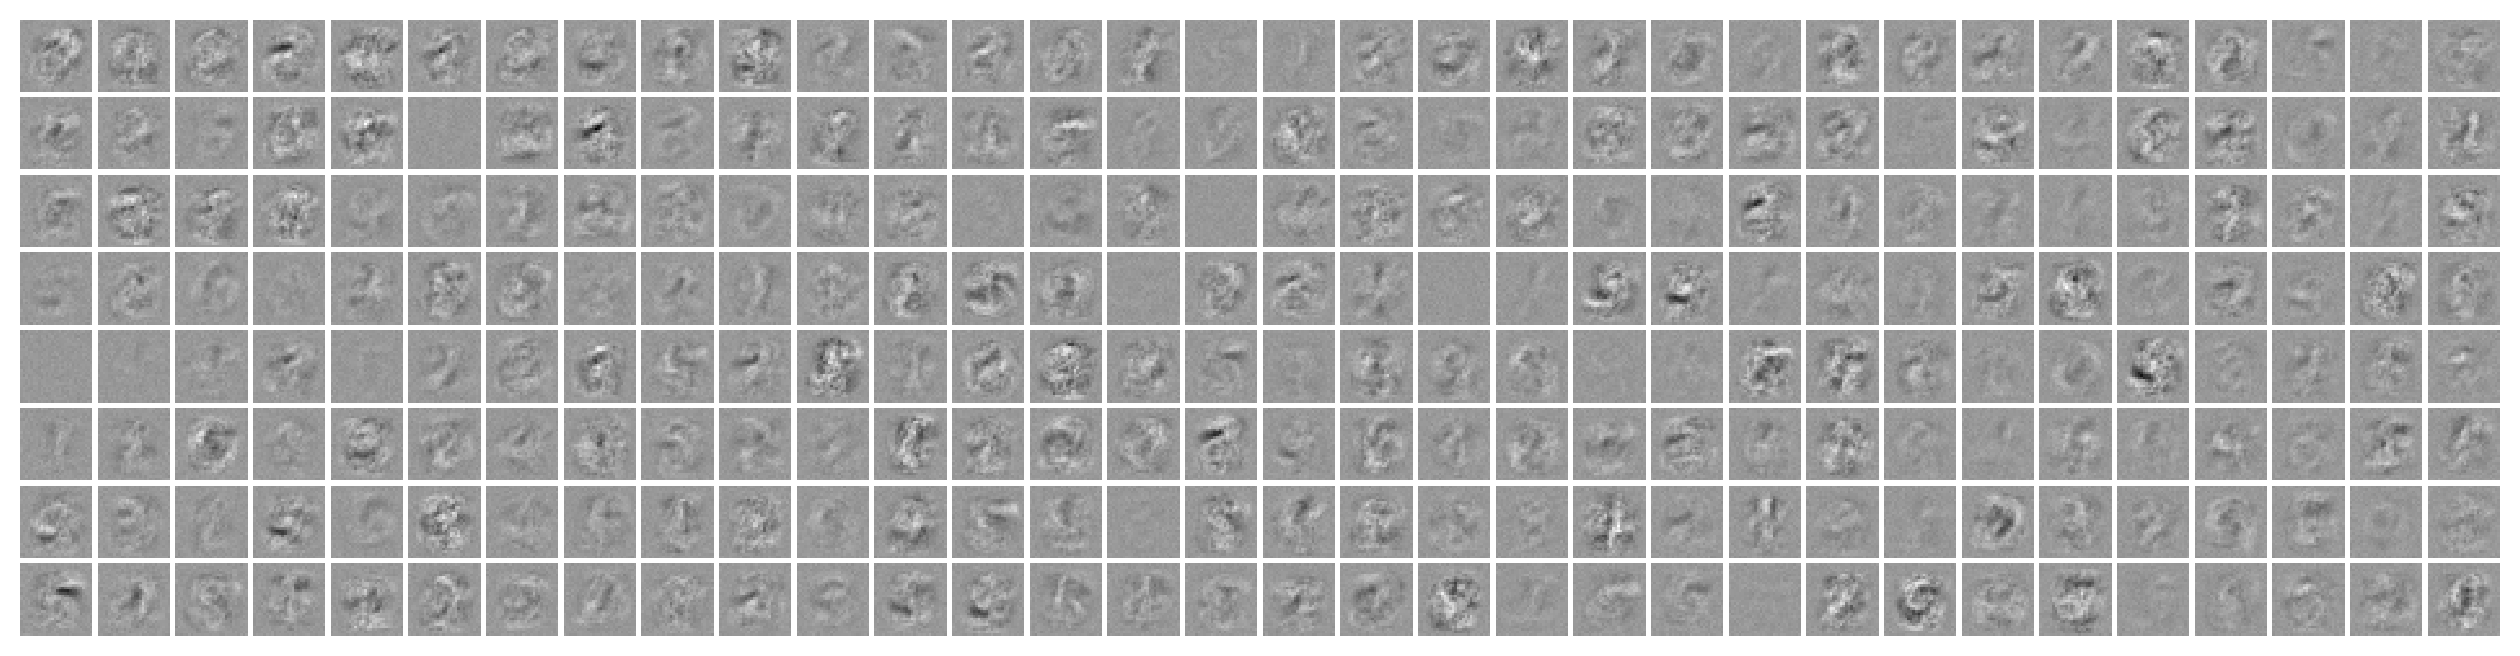


Learning layer 0
Epoch 0:	########################################	elapsed: 1.20s, reconstruction error: 129.00
Epoch 1:	########################################	elapsed: 2.29s, reconstruction error: 129.89
Epoch 2:	########################################	elapsed: 1.30s, reconstruction error: 124.14
Epoch 3:	########################################	elapsed: 1.49s, reconstruction error: 114.50
Epoch 4:	########################################	elapsed: 0.93s, reconstruction error: 97.39
Epoch 5:	########################################	elapsed: 1.84s, reconstruction error: 49.78
Epoch 6:	########################################	elapsed: 2.53s, reconstruction error: 43.34
Epoch 7:	########################################	elapsed: 1.26s, reconstruction error: 41.12
Epoch 8:	########################################	elapsed: 1.99s, reconstruction error: 40.03
Epoch 9:	########################################	elapsed: 1.70s, reconstruction error: 38.13
Epoch 10:	############################

In [ ]:
shallow_mlp = [
    Layer(
        visible_size=VISIBLE_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        activation_fun=relu,
        d_activation_fun=relu_derivative,
        learning_rate=MLP_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=2.0,
    ),
    Layer(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        activation_fun=relu,
        d_activation_fun=relu_derivative,
        learning_rate=MLP_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=1.0,
    ),
    Layer(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=10,
        activation_fun=softmax,
        d_activation_fun=None,
        learning_rate=SOFTMAX_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=4.0,
    ),
]

shallow_dbn = [
    RestrictedBoltzmannMachine(
        visible_size=VISIBLE_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        visible_act_func=sigmoid,
        hidden_act_func=relu,
        learning_rate=RBM_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=2.0,
    ),
    RestrictedBoltzmannMachine(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        visible_act_func=relu,
        hidden_act_func=relu,
        learning_rate=RBM_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=1.0,
    )
]

compare_pretraining_results(
    mlp=shallow_mlp,
    dbn=shallow_dbn,
    train_set=mnist_train_images,
    train_labels=mnist_train_labels,
    validation_set=mnist_test_images,
    validation_labels=mnist_test_labels,
    monitoring_set=monitoring_set,
    batch_size=BATCH_SIZE,
    epochs_count=EPOCHS_COUNT,
)

### Deep ReLU network

Epoch 1:	########################################	elapsed: 1.60s, accuracy: 11.35
Epoch 2:	########################################	elapsed: 1.22s, accuracy: 11.35
Epoch 3:	########################################	elapsed: 1.26s, accuracy: 11.35
Epoch 4:	########################################	elapsed: 1.11s, accuracy: 11.35
Epoch 5:	########################################	elapsed: 1.03s, accuracy: 11.35
Epoch 6:	########################################	elapsed: 1.47s, accuracy: 43.85
Epoch 7:	########################################	elapsed: 1.24s, accuracy: 83.52
Epoch 8:	########################################	elapsed: 1.36s, accuracy: 90.36
Epoch 9:	########################################	elapsed: 1.18s, accuracy: 92.42
Epoch 10:	########################################	elapsed: 1.34s, accuracy: 93.79
Epoch 11:	########################################	elapsed: 1.23s, accuracy: 92.95
Epoch 12:	########################################	elapsed: 1.22s, accuracy: 93.25
Epoch 13:	###

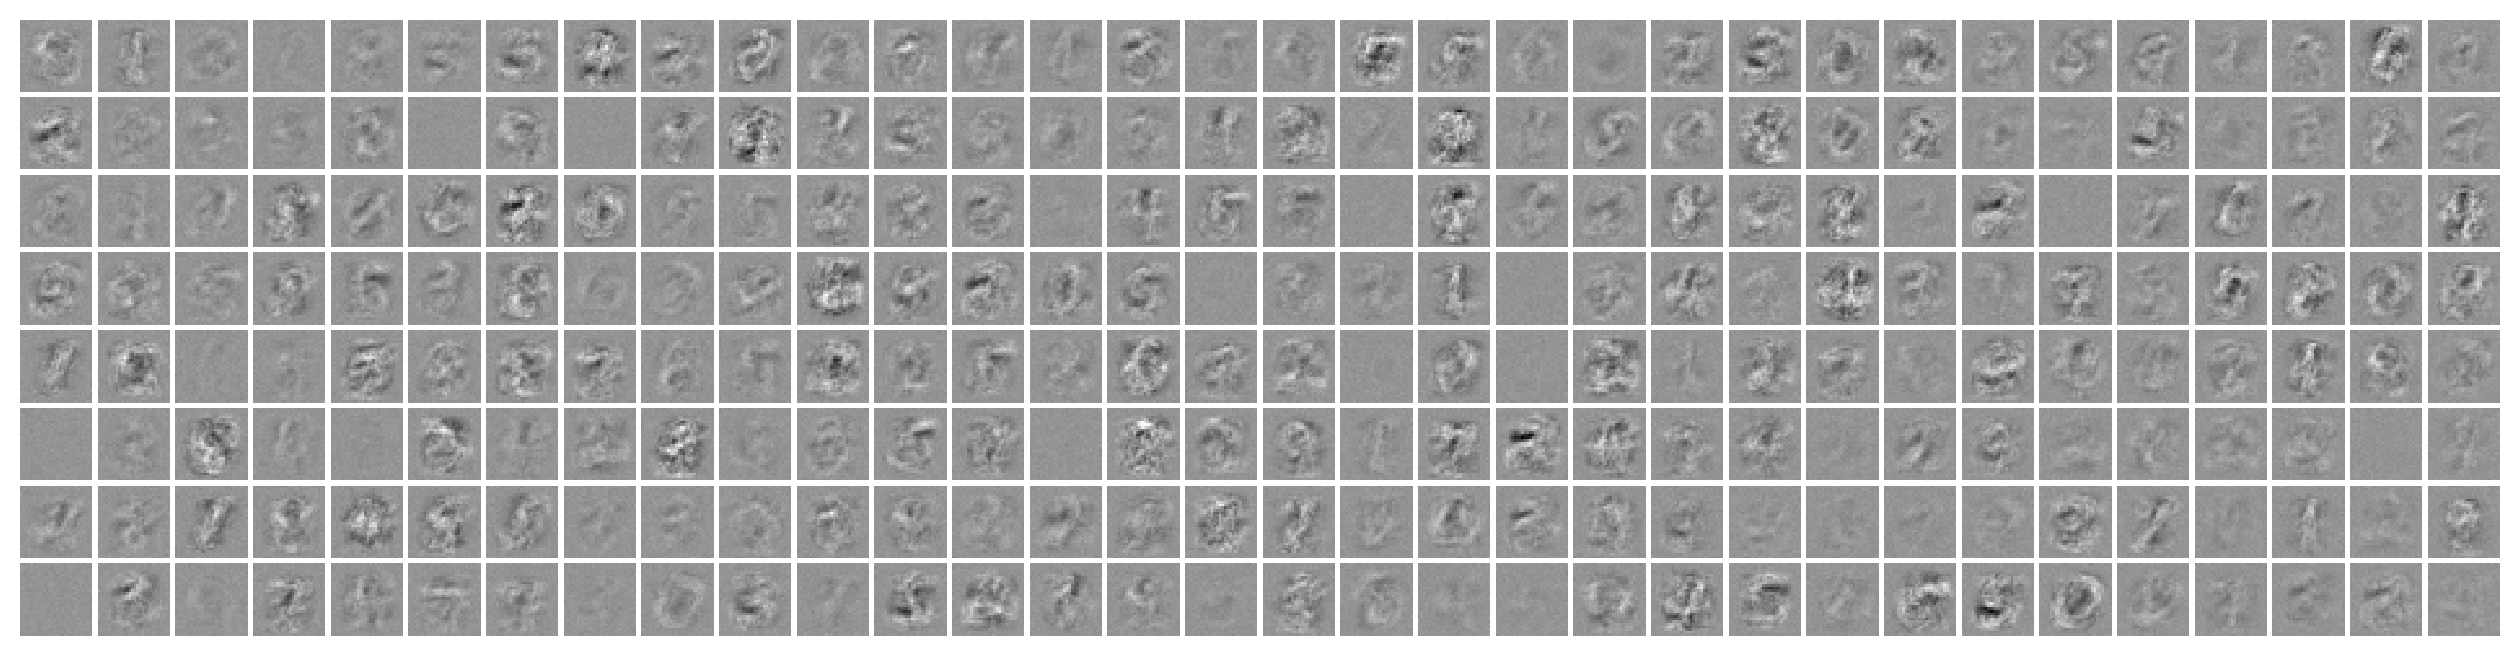


Learning layer 0
Epoch 0:	########################################	elapsed: 0.67s, reconstruction error: 128.86
Epoch 1:	########################################	elapsed: 0.64s, reconstruction error: 129.83
Epoch 2:	########################################	elapsed: 1.05s, reconstruction error: 125.04
Epoch 3:	########################################	elapsed: 0.83s, reconstruction error: 114.36
Epoch 4:	########################################	elapsed: 0.88s, reconstruction error: 95.87
Epoch 5:	########################################	elapsed: 0.91s, reconstruction error: 49.79
Epoch 6:	########################################	elapsed: 0.82s, reconstruction error: 42.84
Epoch 7:	########################################	elapsed: 0.76s, reconstruction error: 41.13
Epoch 8:	########################################	elapsed: 0.82s, reconstruction error: 39.98
Epoch 9:	########################################	elapsed: 0.92s, reconstruction error: 38.37
Epoch 10:	############################

C:\Users\User\AppData\Local\Temp\ipykernel_16468\219424295.py:2: RuntimeWarning: overflow encountered in exp
  activations = 1.0 / (1.0 + np.exp(-batch))


##############################	elapsed: 0.72s, reconstruction error: 15516825600.00
Epoch 1:	########################################	elapsed: 0.49s, reconstruction error: 15543409664.00
Epoch 2:	########################################	elapsed: 0.46s, reconstruction error: 15570015232.00
Epoch 3:	########################################	elapsed: 0.58s, reconstruction error: 15596647424.00
Epoch 4:	########################################	elapsed: 0.47s, reconstruction error: 15623303168.00
Epoch 5:	########################################	elapsed: 0.50s, reconstruction error: 15744701440.00
Epoch 6:	########################################	elapsed: 0.57s, reconstruction error: 15878884352.00
Epoch 7:	########################################	elapsed: 0.38s, reconstruction error: 16013686784.00
Epoch 8:	########################################	elapsed: 0.48s, reconstruction error: 16149097472.00
Epoch 9:	########################################	elapsed: 0.76s, reconstruction error: 1628

Epoch 1:	########################################	elapsed: 1.37s, accuracy: 9.58
Epoch 2:	########################################	elapsed: 1.48s, accuracy: 9.58
Epoch 3:	########################################	elapsed: 1.23s, accuracy: 9.58
Epoch 4:	########################################	elapsed: 1.24s, accuracy: 9.58
Epoch 5:	########################################	elapsed: 1.27s, accuracy: 9.58
Epoch 6:	########################################	elapsed: 1.42s, accuracy: 9.58
Epoch 7:	########################################	elapsed: 1.08s, accuracy: 9.58
Epoch 8:	########################################	elapsed: 1.46s, accuracy: 9.58
Epoch 9:	########################################	elapsed: 1.51s, accuracy: 9.58
Epoch 10:	########################################	elapsed: 1.37s, accuracy: 9.58
Epoch 11:	########################################	elapsed: 1.28s, accuracy: 9.58
Epoch 12:	########################################	elapsed: 1.43s, accuracy: 9.58
Epoch 13:	###############

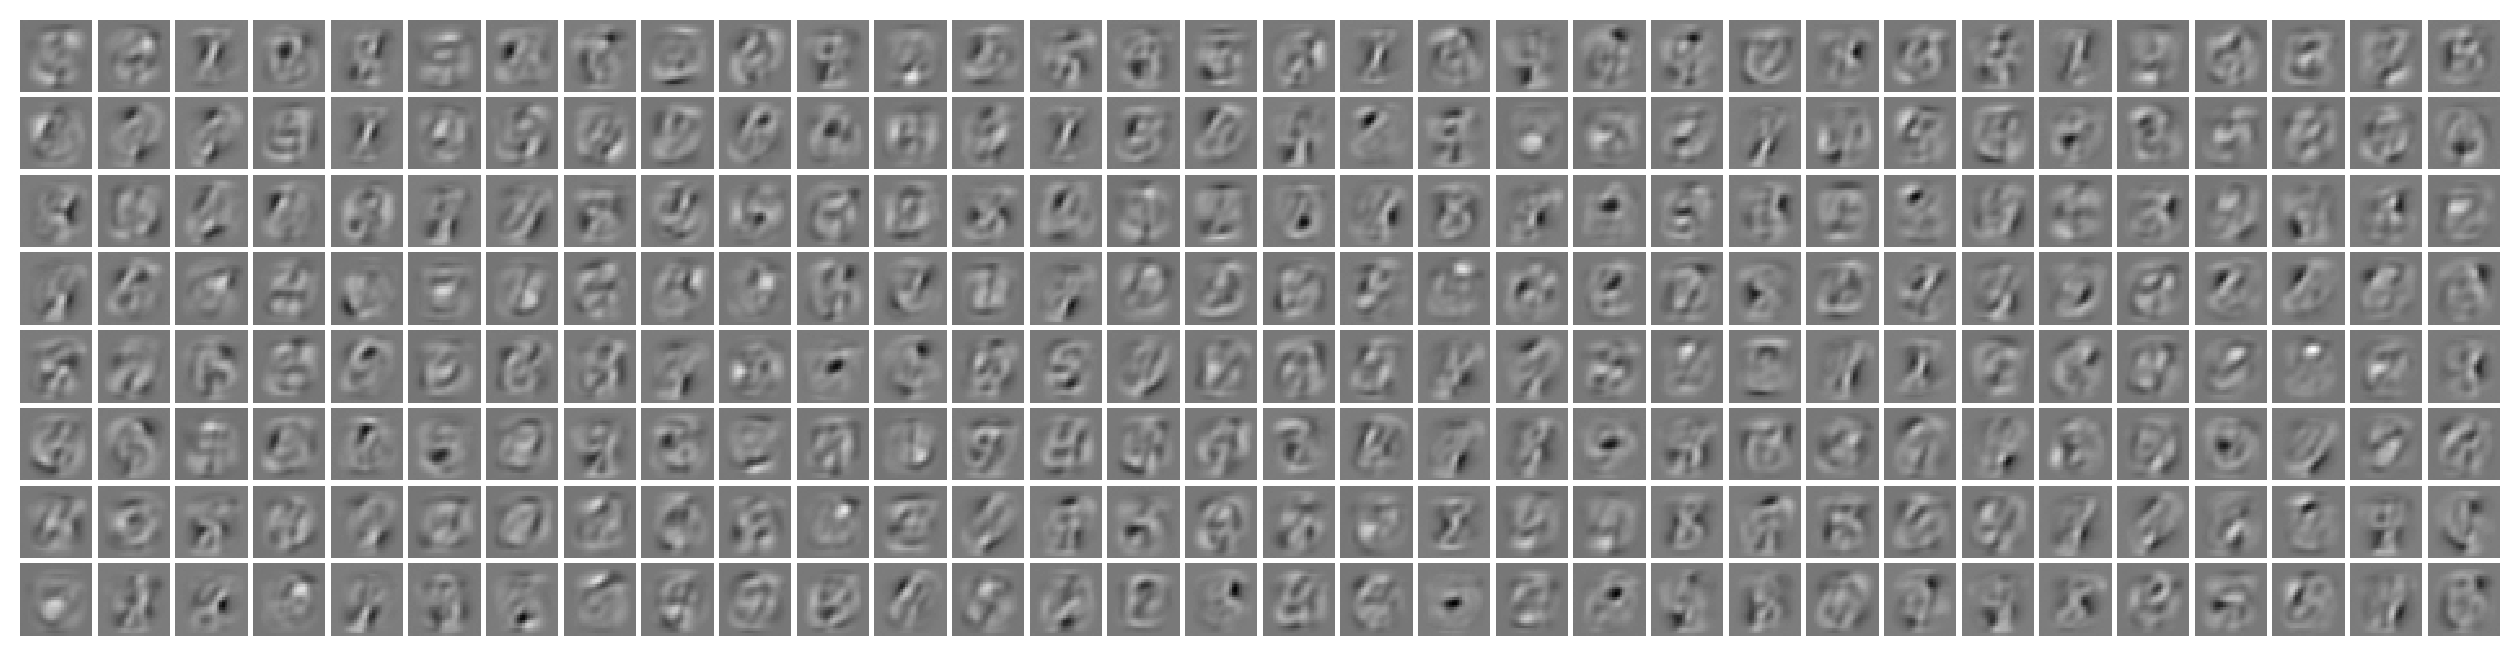

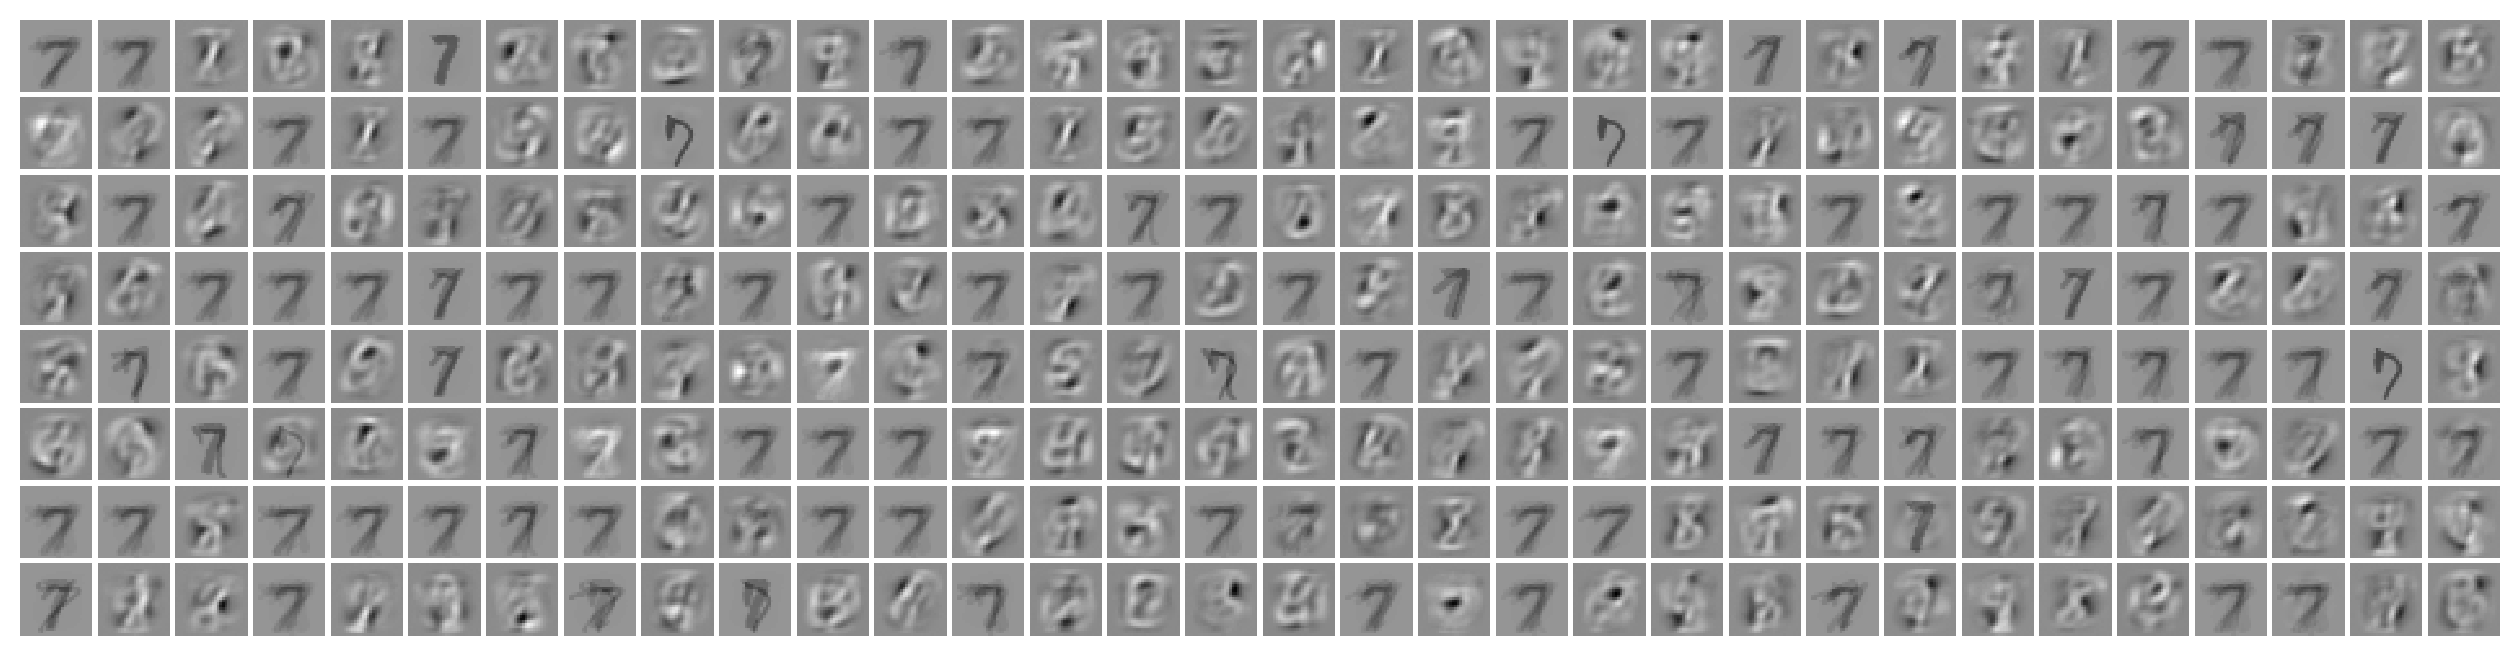

In [ ]:
deep_mlp = [
    Layer(
        visible_size=VISIBLE_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        activation_fun=relu,
        d_activation_fun=relu_derivative,
        learning_rate=MLP_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=2.0,
    ),
    Layer(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        activation_fun=relu,
        d_activation_fun=relu_derivative,
        learning_rate=MLP_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=1.0,
    ),
    Layer(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=2 * HIDDEN_LAYER_SIZE,
        activation_fun=relu,
        d_activation_fun=relu_derivative,
        learning_rate=MLP_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=1.0,
    ),
    Layer(
        visible_size=2 * HIDDEN_LAYER_SIZE,
        hidden_size=10,
        activation_fun=softmax,
        d_activation_fun=None,
        learning_rate=SOFTMAX_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=4.0,
    ),
]

deep_dbn = [
    RestrictedBoltzmannMachine(
        visible_size=VISIBLE_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        visible_act_func=sigmoid,
        hidden_act_func=relu,
        learning_rate=RBM_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=2.0,
    ),
    RestrictedBoltzmannMachine(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        visible_act_func=relu,
        hidden_act_func=relu,
        learning_rate=RBM_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=1.0,
    ),
    RestrictedBoltzmannMachine(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=2 * HIDDEN_LAYER_SIZE,
        visible_act_func=relu,
        hidden_act_func=relu,
        learning_rate=RBM_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=1.0,
    )
]

compare_pretraining_results(
    mlp=deep_mlp,
    dbn=deep_dbn,
    train_set=mnist_train_images,
    train_labels=mnist_train_labels,
    validation_set=mnist_test_images,
    validation_labels=mnist_test_labels,
    monitoring_set=monitoring_set,
    batch_size=BATCH_SIZE,
    epochs_count=EPOCHS_COUNT,
)